<a href="https://colab.research.google.com/github/zahrafarhan/hydraulic-pump-condition-monitoring/blob/main/hydraulic_condition_monitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files

uploaded = files.upload()
print(uploaded.keys())


Saving archive.zip to archive (1).zip
dict_keys(['archive (1).zip'])
dict_keys(['archive (1).zip'])


In [5]:
print(uploaded.keys())

dict_keys(['archive (1).zip'])


In [6]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("hydraulic_data")

print("Dataset extracted")

Dataset extracted


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [8]:
DATA_FOLDER = "hydraulic_data"

In [9]:
import os

print(os.path.exists(os.path.join(DATA_FOLDER, "PS1.txt")))

True


In [10]:
ps1 = np.loadtxt(
    os.path.join(DATA_FOLDER, "PS1.txt"),
    delimiter="\t"
)

print(ps1.shape)

(2205, 6000)


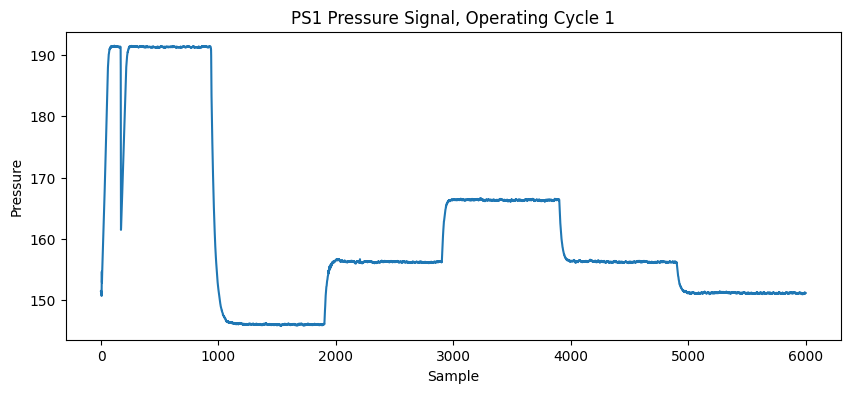

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(ps1[0])
plt.title("PS1 Pressure Signal, Operating Cycle 1")
plt.xlabel("Sample")
plt.ylabel("Pressure")
plt.show()

In [12]:
def extract_features(signal_data, sensor_name):
    features = pd.DataFrame({
        f"{sensor_name}_mean": np.mean(signal_data, axis=1),
        f"{sensor_name}_std": np.std(signal_data, axis=1),
        f"{sensor_name}_min": np.min(signal_data, axis=1),
        f"{sensor_name}_max": np.max(signal_data, axis=1),
        f"{sensor_name}_range": np.ptp(signal_data, axis=1),
        f"{sensor_name}_rms": np.sqrt(
            np.mean(signal_data ** 2, axis=1)
        )
    })

    return features

In [13]:
ps1_features = extract_features(ps1, "PS1")
ps1_features.head()

,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_range,PS1_rms
0,160.673492,13.938147,145.83,191.51,45.68,161.276914
1,160.603320,14.117791,145.73,191.47,45.74,161.222636
2,160.347720,14.191436,145.37,191.41,46.04,160.974495
3,160.188088,14.226617,145.14,191.34,46.20,160.818594
4,160.000472,14.275244,144.95,191.41,46.46,160.636028


In [14]:
ps1_features = extract_features(ps1, "PS1")
ps1_features.head()

,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_range,PS1_rms
0,160.673492,13.938147,145.83,191.51,45.68,161.276914
1,160.603320,14.117791,145.73,191.47,45.74,161.222636
2,160.347720,14.191436,145.37,191.41,46.04,160.974495
3,160.188088,14.226617,145.14,191.34,46.20,160.818594
4,160.000472,14.275244,144.95,191.41,46.46,160.636028


In [15]:
feature_tables = []

for sensor in sensors:
    file_path = os.path.join(DATA_FOLDER, f"{sensor}.txt")

    sensor_data = np.loadtxt(
        file_path,
        delimiter="\t"
    )

    sensor_features = extract_features(
        sensor_data,
        sensor
    )

    feature_tables.append(sensor_features)

X = pd.concat(feature_tables, axis=1)

print(X.shape)
X.head()

NameError: name 'sensors' is not defined

In [16]:
sensors = [
    "PS1",
    "PS2",
    "PS3",
    "FS1",
    "TS1",
    "VS1",
    "EPS1"
]

print(sensors)

['PS1', 'PS2', 'PS3', 'FS1', 'TS1', 'VS1', 'EPS1']


In [18]:
feature_tables = []

for sensor in sensors:
    file_path = os.path.join(DATA_FOLDER, f"{sensor}.txt")

    sensor_data = np.loadtxt(
        file_path,
        delimiter="\t"
    )

    sensor_features = extract_features(
        sensor_data,
        sensor
    )

    feature_tables.append(sensor_features)

X = pd.concat(feature_tables, axis=1)

print(X.shape)
X.head()

(2205, 42)


,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_range,PS1_rms,PS2_mean,PS2_std,PS2_min,PS2_max,...,VS1_min,VS1_max,VS1_range,VS1_rms,EPS1_mean,EPS1_std,EPS1_min,EPS1_max,EPS1_range,EPS1_rms
0,160.673492,13.938147,145.83,191.51,45.68,161.276914,109.466914,47.110581,0.0,156.99,...,0.532,0.624,0.092,0.577575,2538.929167,185.600652,2339.8,2951.6,611.8,2545.704012
1,160.603320,14.117791,145.73,191.47,45.74,161.222636,109.354890,47.041690,0.0,157.56,...,0.524,0.626,0.102,0.566494,2531.498900,189.924260,2332.0,2947.4,615.4,2538.613382
2,160.347720,14.191436,145.37,191.41,46.04,160.974495,109.158845,46.988144,0.0,156.97,...,0.529,0.662,0.133,0.577683,2519.928000,190.720954,2318.6,2939.8,621.2,2527.135059
3,160.188088,14.226617,145.14,191.34,46.20,160.818594,109.064807,46.968307,0.0,156.44,...,0.527,0.645,0.118,0.570233,2511.541633,191.254667,2310.8,2929.6,618.8,2518.813158
4,160.000472,14.275244,144.95,191.41,46.46,160.636028,108.931434,46.871040,0.0,158.13,...,0.524,0.660,0.136,0.578321,2503.449500,191.242430,2301.8,2923.8,622.0,2510.743529


In [19]:
profile = pd.read_csv(
    os.path.join(DATA_FOLDER, "profile.txt"),
    sep=r"\s+",
    header=None
)

profile.columns = [
    "cooler_condition",
    "valve_condition",
    "pump_leakage",
    "accumulator_condition",
    "stability_flag"
]

profile.head()

,cooler_condition,valve_condition,pump_leakage,accumulator_condition,stability_flag
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1
3,3,100,0,130,1
4,3,100,0,130,1


In [20]:
y = profile["pump_leakage"]

print(y.value_counts())

pump_leakage
0    1221
2     492
1     492
Name: count, dtype: int64


In [21]:
y = profile["pump_leakage"]

print(y.value_counts())

pump_leakage
0    1221
2     492
1     492
Name: count, dtype: int64


In [22]:
print(X.isnull().sum().sum())

0


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [24]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [25]:
predictions = model.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9977324263038548


In [27]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)


Accuracy: 0.9977324263038548


In [28]:
print(
    classification_report(
        y_test,
        predictions,
        target_names=[
            "No leakage",
            "Weak leakage",
            "Severe leakage"
        ]
    )
)

                precision    recall  f1-score   support

    No leakage       1.00      1.00      1.00       244
  Weak leakage       1.00      0.99      0.99        99
Severe leakage       0.99      1.00      0.99        98

      accuracy                           1.00       441
     macro avg       1.00      1.00      1.00       441
  weighted avg       1.00      1.00      1.00       441



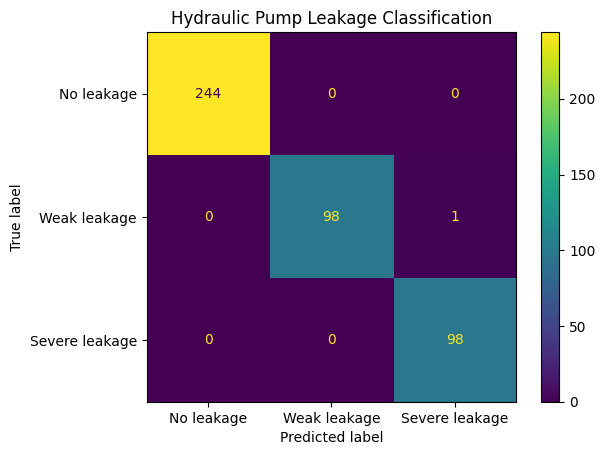

In [29]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=[
        "No leakage",
        "Weak leakage",
        "Severe leakage"
    ]
)

plt.title("Hydraulic Pump Leakage Classification")
plt.show()

In [30]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(15))

FS1_rms      0.199677
FS1_mean     0.199039
EPS1_mean    0.061885
EPS1_rms     0.054153
FS1_std      0.051777
PS3_mean     0.046358
EPS1_max     0.044531
EPS1_min     0.041722
PS3_rms      0.041231
PS1_max      0.035516
PS1_min      0.020881
TS1_rms      0.015313
PS1_mean     0.015000
PS1_rms      0.014453
TS1_mean     0.013062
dtype: float64


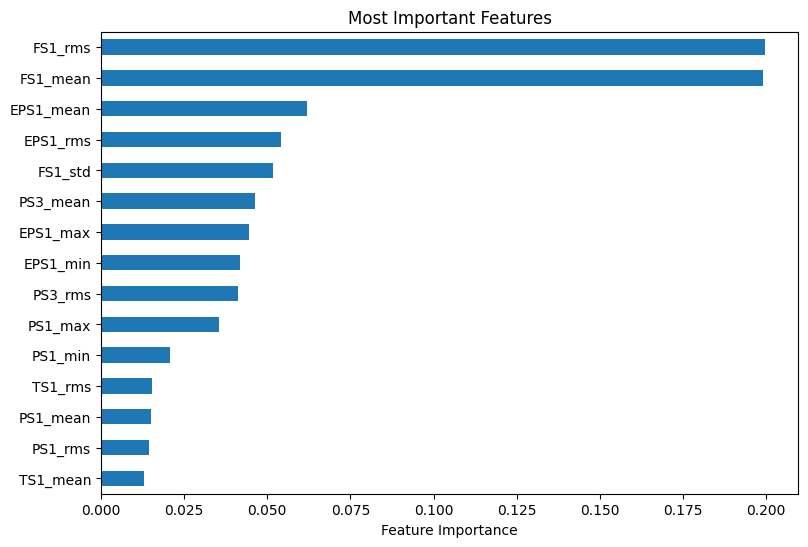

In [31]:
feature_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Most Important Features")
plt.xlabel("Feature Importance")
plt.show()

In [32]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced"
        )
    )
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, logistic_predictions)
)

Logistic Regression Accuracy: 0.9931972789115646


In [33]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, predictions)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.993197
1,Random Forest,0.997732


In [34]:
analysis_data = X.copy()
analysis_data["pump_leakage"] = y

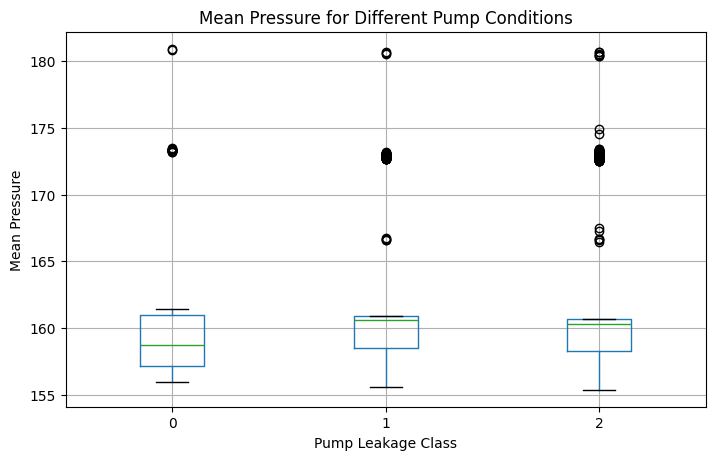

In [35]:
analysis_data.boxplot(
    column="PS1_mean",
    by="pump_leakage",
    figsize=(8, 5)
)

plt.title("Mean Pressure for Different Pump Conditions")
plt.suptitle("")
plt.xlabel("Pump Leakage Class")
plt.ylabel("Mean Pressure")
plt.show()

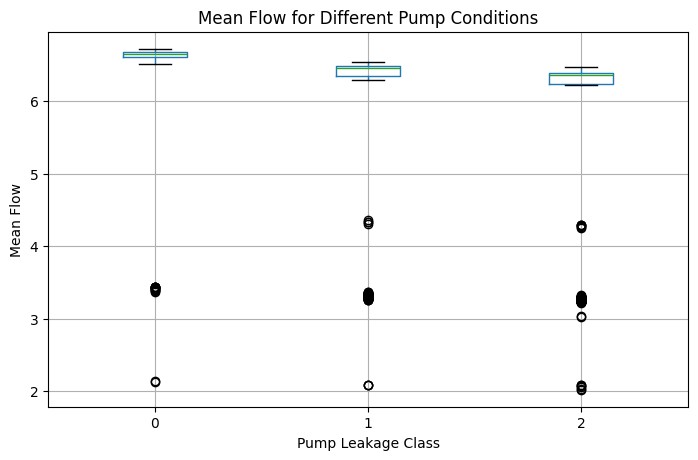

In [36]:
analysis_data.boxplot(
    column="FS1_mean",
    by="pump_leakage",
    figsize=(8, 5)
)

plt.title("Mean Flow for Different Pump Conditions")
plt.suptitle("")
plt.xlabel("Pump Leakage Class")
plt.ylabel("Mean Flow")
plt.show()

In [37]:
import joblib

joblib.dump(
    model,
    "hydraulic_pump_fault_model.pkl"
)

['hydraulic_pump_fault_model.pkl']